# Optuna Hyperparameter Search — Chest X-Ray Pneumonia Ensemble

This notebook **starts from your existing 4 checkpoints** (`resnet50_best.pth`, `vgg19_best.pth`,
`swin_best.pth`, `deit_best.pth`) and runs **Bayesian hyperparameter optimisation** on top —
no random guesses, no manual tuning.

## Two-phase optimisation strategy

| Phase | What it tunes | Needs training? | Time budget |
|-------|---------------|-----------------|-------------|
| **Phase 1 — Inference-side** | Per-model temperature, per-model ensemble weights, decision threshold | ❌ No | ~30–60 min |
| **Phase 2 — Training-side** *(optional)* | LR, weight decay, dropout, label smoothing of the weakest member | ✅ Yes (short trial epochs) | ~6–10 h |
| Final retrain + ensemble + GradCAM | – | ✅ Only weakest model | ~1–2 h |

Combined budget fits in **~12–14 h** of your 23 h Kaggle quota.

## How Optuna actually picks hyperparameters (not random!)

Optuna uses **TPE (Tree-structured Parzen Estimator)**, a Bayesian optimiser:

1. **Trial 1–10** — drawn semi-randomly to seed the search space (warm-up).
2. After each trial, Optuna fits two density models:
   - `l(x)` — distribution of HPs of trials in the **best** quantile (e.g. top 25% F1).
   - `g(x)` — distribution of HPs of the rest.
3. **Next trial** is sampled where the ratio `l(x) / g(x)` is largest, i.e. where good trials are *most likely to live*.
4. Combined with **MedianPruner / HyperbandPruner**, Optuna kills training-side trials that under-perform after a few epochs, freeing budget for promising trials.

This is **strictly better than grid or random search** for any non-trivial number of HPs (Bergstra et al. 2011; Akiba et al. 2019).

## 0. Install dependencies

In [1]:
!pip install -q optuna==4.0.0 grad-cam==1.5.4 plotly==5.24.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 94.8 MB/s eta 0:00:00:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.8/362.8 kB 26.9 MB/s eta 0:00:00


## 1. Imports & reproducibility

In [2]:
import os, sys, time, math, random, copy, gc, json, subprocess, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler

import torchvision
import torchvision.transforms as T
from torchvision import models as tv_models

import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
)

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import HyperbandPruner

# AMP
try:
    from torch.amp import autocast as _autocast, GradScaler as _GradScaler
    def make_scaler(): return _GradScaler('cuda', enabled=torch.cuda.is_available())
    def amp_ctx():     return _autocast('cuda', enabled=torch.cuda.is_available())
except ImportError:
    from torch.cuda.amp import autocast as _autocast, GradScaler as _GradScaler
    def make_scaler(): return _GradScaler(enabled=torch.cuda.is_available())
    def amp_ctx():     return _autocast(enabled=torch.cuda.is_available())

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')
print(f'timm   : {timm.__version__}')
print(f'optuna : {optuna.__version__}')

Device : cuda
PyTorch: 2.10.0+cu128
timm   : 1.0.25
optuna : 4.0.0


## 2. Configuration

Set `RUN_PHASE_2 = True` to also retrain the weakest member with a training-side HP search
(adds ~6–10 h). Set `RUN_PHASE_2 = False` to only run the fast inference-side search.

In [3]:
CFG = dict(
    img_size            = 224,
    batch_size          = 16,
    num_workers         = 4,                    # bumped from 2 to 4 — faster data loading
    num_classes         = 2,
    class_names         = ['NORMAL', 'PNEUMONIA'],
    val_frac            = 0.10,
    save_dir            = '/kaggle/working',

    # Inference-time settings (must match the recipe used to train the checkpoints)
    use_se_block        = True,
    dropout             = 0.40,
    tta                 = True,                 # h-flip TTA when caching predictions

    # Phase 1 — inference-side Optuna
    n_trials_phase1     = 200,                  # cheap (no training); can go to 500
    objective_metric    = 'f1',                 # f1 | accuracy | balanced_acc

    # Phase 2 — training-side Optuna (optional)
    RUN_PHASE_2         = True,
    n_trials_phase2     = 15,                   # 15-20 reasonable; ~6-10 h on T4
    trial_epochs_freeze = 1,                    # SHORT trials for HP search
    trial_epochs_finetune = 3,
    full_epochs_freeze  = 3,                    # FULL retrain with best HPs
    full_epochs_finetune= 8,
    early_stop_patience = 3,
    grad_clip           = 1.0,
)
os.makedirs(CFG['save_dir'], exist_ok=True)
print(CFG)

{'img_size': 224, 'batch_size': 16, 'num_workers': 4, 'num_classes': 2, 'class_names': ['NORMAL', 'PNEUMONIA'], 'val_frac': 0.1, 'save_dir': '/kaggle/working', 'use_se_block': True, 'dropout': 0.4, 'tta': True, 'n_trials_phase1': 200, 'objective_metric': 'f1', 'RUN_PHASE_2': True, 'n_trials_phase2': 15, 'trial_epochs_freeze': 1, 'trial_epochs_finetune': 3, 'full_epochs_freeze': 3, 'full_epochs_finetune': 8, 'early_stop_patience': 3, 'grad_clip': 1.0}


## 3. Locate dataset & checkpoints

1. **Chest X-Ray images (`paultimothymooney/chest-xray-pneumonia`)**
   • **Default**: downloaded automatically via **`kagglehub`** when **Internet is ON** in notebook
   Settings. You do **not** need to attach the image bundle with *+ Add Data* in that mode.
   • **Offline/air-gapped kernels**: manually add Paul Mooney’s dataset with **+ Add Data** so
     it mounts under `/kaggle/input`; the fallback search will pick it up.

2. **Your 4 checkpoints** (`*_best.pth`)
   Upload them once as your own **private dataset** (`+ Add Data`) or paste them
   directly into `/kaggle/working` from a prior kernel output.

The code cell below auto-discovers the split root and the checkpoints.

In [4]:
DATASET_SLUG = 'paultimothymooney/chest-xray-pneumonia'


def _find_splits_root_under(base):
    base = os.path.abspath(base)
    if not os.path.isdir(base):
        return None
    for root, dirs, _ in os.walk(base):
        if all(s in dirs for s in ['train', 'test', 'val']):
            return root
    return None


def find_dataset():
    """Prefer `kagglehub` when Internet exists; otherwise scan /kaggle/input."""
    input_root = '/kaggle/input'
    try:
        import importlib.util
        spec = importlib.util.find_spec('kagglehub')
        if spec is None:
            print('Installing kagglehub …')
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'kagglehub'])
            importlib.invalidate_caches()
        import kagglehub
        print(f'Downloading dataset via kagglehub: {DATASET_SLUG}')
        dl_path = kagglehub.dataset_download(DATASET_SLUG)
        found = _find_splits_root_under(dl_path)
        if found is None:
            raise FileNotFoundError(f'Could not find train/test/val under {dl_path}')
        print('Using downloaded path:', found)
        return found
    except Exception as e:
        print('kagglehub download failed:', e)

    if os.path.isdir(input_root):
        found = _find_splits_root_under(input_root)
        if found is not None:
            print('Using mounted input path:', found)
            return found

    raise FileNotFoundError(
        'Enable Internet so kagglehub can download the Chest X-Ray dataset, '
        'or attach the dataset via + Add Data.'
    )


MODEL_NAMES = ['resnet50', 'vgg19', 'swin', 'deit']

def find_checkpoints(model_names):
    """Search common Kaggle paths for `{name}_best.pth`."""
    search_roots = ['/kaggle/working', '/kaggle/input']
    found = {}
    for root in search_roots:
        if not os.path.isdir(root):
            continue
        for dirpath, _, files in os.walk(root):
            for f in files:
                if not f.endswith('_best.pth'):
                    continue
                name = f.replace('_best.pth', '')
                if name in model_names and name not in found:
                    found[name] = os.path.join(dirpath, f)
    missing = sorted(set(model_names) - set(found.keys()))
    if missing:
        raise FileNotFoundError(
            f'Missing checkpoints for: {missing}\n'
            f'Upload them as a Kaggle dataset and re-run.\nFound so far: {found}'
        )
    return found


BASE_DIR  = find_dataset()
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR   = os.path.join(BASE_DIR, 'val')
TEST_DIR  = os.path.join(BASE_DIR, 'test')
print('Dataset base:', BASE_DIR)

CKPT = find_checkpoints(MODEL_NAMES)
print('\nCheckpoints found:')
for k, v in CKPT.items():
    print(f'  {k:9s}  {v}')

Using downloaded path: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
Dataset base: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray

Checkpoints found:
  swin       /kaggle/input/datasets/sudiptoroyshawon/my-ensemble-weights/swin_best.pth
  resnet50   /kaggle/input/datasets/sudiptoroyshawon/my-ensemble-weights/resnet50_best.pth
  deit       /kaggle/input/datasets/sudiptoroyshawon/my-ensemble-weights/deit_best.pth
  vgg19      /kaggle/input/datasets/sudiptoroyshawon/my-ensemble-weights/vgg19_best.pth


## 4. Dataset, transforms, splits

Same recipe as the training notebook so the splits & preprocessing line up exactly with the
checkpoints you already trained.

In [5]:
class XRayDataset(Dataset):
    def __init__(self, root_dir, class_names, transform=None, return_path=False):
        self.transform    = transform
        self.return_path  = return_path
        self.class_names  = class_names
        self.class_to_idx = {c: i for i, c in enumerate(class_names)}
        self.samples      = []
        for cls in class_names:
            d = os.path.join(root_dir, cls)
            if not os.path.exists(d):
                continue
            for f in os.listdir(d):
                if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append((os.path.join(d, f), self.class_to_idx[cls]))
        self._clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    def __len__(self):
        return len(self.samples)

    def _apply_clahe(self, img_rgb):
        lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
        lab[:, :, 0] = self._clahe.apply(lab[:, :, 0])
        out = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        out = cv2.GaussianBlur(out, (3, 3), sigmaX=0.5)
        return Image.fromarray(out)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img_bgr = cv2.imread(path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        pil_img = self._apply_clahe(img_rgb)
        out = self.transform(pil_img) if self.transform else pil_img
        return (out, label, path) if self.return_path else (out, label)

    @property
    def targets(self):
        return [s[1] for s in self.samples]


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG = CFG['img_size']

train_tf = T.Compose([
    T.Resize(256), T.RandomCrop(IMG, padding=16, padding_mode='reflect'),
    T.RandomHorizontalFlip(p=0.5), T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.15, contrast=0.15),
    T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    T.RandomErasing(p=0.25, scale=(0.02, 0.15), ratio=(0.3, 3.3)),
])
eval_tf = T.Compose([
    T.Resize(256), T.CenterCrop(IMG),
    T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Same stratified split as the training notebook (seed=42 makes it reproducible)
full_train_aug  = XRayDataset(TRAIN_DIR, CFG['class_names'], transform=train_tf)
full_train_eval = XRayDataset(TRAIN_DIR, CFG['class_names'], transform=eval_tf)

t_idx, v_idx = train_test_split(
    np.arange(len(full_train_aug)),
    test_size=CFG['val_frac'],
    stratify=np.asarray(full_train_aug.targets),
    random_state=SEED,
)
train_ds = Subset(full_train_aug,  t_idx.tolist())
val_ds   = Subset(full_train_eval, v_idx.tolist())
test_ds  = XRayDataset(TEST_DIR, CFG['class_names'], transform=eval_tf)

print(f'train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}')

# WeightedRandomSampler for training side (used in Phase 2 only)
train_targets = np.asarray(full_train_aug.targets)[t_idx]
class_count   = Counter(train_targets.tolist())
sample_w      = torch.from_numpy(
    np.array([1.0 / class_count[t] for t in train_targets], dtype=np.float64)
)
sampler = WeightedRandomSampler(sample_w, num_samples=len(train_targets), replacement=True)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], sampler=sampler,
                          num_workers=CFG['num_workers'], pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=True)

train=4694  val=522  test=624


## 5. Model builders (must mirror what produced the checkpoints)

In [6]:
class SEBlock1D(nn.Module):
    def __init__(self, in_features, reduction=8):
        super().__init__()
        hidden = max(in_features // reduction, 8)
        self.fc1 = nn.Linear(in_features, hidden)
        self.fc2 = nn.Linear(hidden, in_features)
    def forward(self, x):
        s = F.relu(self.fc1(x), inplace=True)
        return x * torch.sigmoid(self.fc2(s))


def build_head(in_features, num_classes, dropout, use_se):
    layers = []
    if use_se:
        layers.append(SEBlock1D(in_features))
    layers += [
        nn.Linear(in_features, 512),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(512, num_classes),
    ]
    return nn.Sequential(*layers)


class ResNet50Wrapper(nn.Module):
    def __init__(self, num_classes, dropout, use_se, pretrained=True):
        super().__init__()
        weights = tv_models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        m = tv_models.resnet50(weights=weights)
        in_f = m.fc.in_features
        m.fc = nn.Identity()
        self.backbone = m
        self.head     = build_head(in_f, num_classes, dropout, use_se)
    def forward(self, x):
        return self.head(self.backbone(x))


class VGG19Wrapper(nn.Module):
    def __init__(self, num_classes, dropout, use_se, pretrained=True):
        super().__init__()
        weights = tv_models.VGG19_BN_Weights.IMAGENET1K_V1 if pretrained else None
        m = tv_models.vgg19_bn(weights=weights)
        self.backbone = m.features
        self.gap      = nn.AdaptiveAvgPool2d(1)
        self.head     = build_head(512, num_classes, dropout, use_se)
    def forward(self, x):
        x = self.backbone(x); x = self.gap(x).flatten(1)
        return self.head(x)


class TimmWrapper(nn.Module):
    def __init__(self, model_name, num_classes, dropout, use_se, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        self.head     = build_head(self.backbone.num_features, num_classes, dropout, use_se)
    def forward(self, x):
        return self.head(self.backbone(x))


def make_model(name, dropout=None, use_se=None, pretrained=False):
    """Build a fresh model architecture (random init by default since we'll load weights)."""
    d  = CFG['dropout']      if dropout is None else dropout
    se = CFG['use_se_block'] if use_se   is None else use_se
    if name == 'resnet50':
        return ResNet50Wrapper(CFG['num_classes'], d, se, pretrained=pretrained)
    if name == 'vgg19':
        return VGG19Wrapper(CFG['num_classes'], d, se, pretrained=pretrained)
    if name == 'swin':
        return TimmWrapper('swin_base_patch4_window7_224', CFG['num_classes'], d, se, pretrained=pretrained)
    if name == 'deit':
        return TimmWrapper('deit_base_patch16_224', CFG['num_classes'], d, se, pretrained=pretrained)
    raise ValueError(name)


# Sanity: load each checkpoint to confirm architecture matches
for name in MODEL_NAMES:
    m = make_model(name, pretrained=False)
    state = torch.load(CKPT[name], map_location='cpu')
    miss, unexp = m.load_state_dict(state, strict=False)
    if miss or unexp:
        print(f'  {name}: missing={len(miss)}  unexpected={len(unexp)}  '
              f'(non-zero values may indicate wrong head config)')
    else:
        print(f'  {name}: state dict loads cleanly ({sum(p.numel() for p in m.parameters())/1e6:.1f}M params)')
    del m
gc.collect()

  resnet50: state dict loads cleanly (25.6M params)
  vgg19: state dict loads cleanly (20.4M params)
  swin: state dict loads cleanly (87.5M params)
  deit: state dict loads cleanly (86.3M params)


8

## 6. Cache base predictions (run each checkpoint **once** with TTA)

Optuna will evaluate hundreds of HP combinations on these cached arrays — no GPU forward pass per
trial, so Phase 1 reduces to NumPy arithmetic. This is the key to making 200 trials finish in
minutes rather than hours.

In [7]:
@torch.no_grad()
def collect_logits(model, loader, use_tta=True):
    model.eval()
    logits_all, labels_all = [], []
    for batch in loader:
        x, y = batch[0], batch[1]
        x = x.to(DEVICE, non_blocking=True)
        with amp_ctx():
            logits = model(x)
            if use_tta:
                logits = (logits + model(torch.flip(x, dims=[3]))) / 2.0
        logits_all.append(logits.float().cpu())
        labels_all.append(y)
    return torch.cat(logits_all).numpy(), torch.cat(labels_all).numpy()


val_logits, test_logits = {}, {}
val_labels = test_labels = None

for name in MODEL_NAMES:
    print(f'Caching predictions: {name}')
    model = make_model(name, pretrained=False).to(DEVICE)
    model.load_state_dict(torch.load(CKPT[name], map_location=DEVICE))

    vl, vy = collect_logits(model, val_loader,  use_tta=CFG['tta'])
    tl, ty = collect_logits(model, test_loader, use_tta=CFG['tta'])

    val_logits [name] = vl;  test_logits[name] = tl
    if val_labels is None:
        val_labels  = vy; test_labels = ty
    else:
        assert np.array_equal(val_labels,  vy)
        assert np.array_equal(test_labels, ty)

    val_acc  = accuracy_score(vy, vl.argmax(1))
    test_acc = accuracy_score(ty, tl.argmax(1))
    print(f'  val_acc={val_acc:.4f}   test_acc={test_acc:.4f}')

    del model; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

# Stack as (M, N, C)
val_L  = np.stack([val_logits [n] for n in MODEL_NAMES], axis=0)
test_L = np.stack([test_logits[n] for n in MODEL_NAMES], axis=0)
print('val_L:', val_L.shape, '  test_L:', test_L.shape)

Caching predictions: resnet50
  val_acc=0.9655   test_acc=0.9006
Caching predictions: vgg19
  val_acc=0.9617   test_acc=0.9022
Caching predictions: swin
  val_acc=0.9559   test_acc=0.9199
Caching predictions: deit
  val_acc=0.9693   test_acc=0.9038
val_L: (4, 522, 2)   test_L: (4, 624, 2)


### 6.1 Baseline ensemble (un-tuned soft voting + threshold 0.5)

This is the number Optuna has to beat.

In [8]:
def softmax_np(x, axis):
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)


def _metrics(y_true, y_pred):
    return dict(
        acc =accuracy_score(y_true, y_pred),
        prec=precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        rec =recall_score(   y_true, y_pred, pos_label=1, zero_division=0),
        f1  =f1_score(       y_true, y_pred, pos_label=1, zero_division=0),
    )


def baseline_soft_vote(L):
    probs = softmax_np(L, axis=2).mean(axis=0)
    return probs.argmax(1)


print('Baseline (untuned soft-voting, threshold=0.5):')
val_pred_base  = baseline_soft_vote(val_L)
test_pred_base = baseline_soft_vote(test_L)
val_base_metrics  = _metrics(val_labels,  val_pred_base)
test_base_metrics = _metrics(test_labels, test_pred_base)
print('  Validation:', {k: round(v, 4) for k, v in val_base_metrics.items()})
print('  Test:      ', {k: round(v, 4) for k, v in test_base_metrics.items()})

Baseline (untuned soft-voting, threshold=0.5):
  Validation: {'acc': 0.9655, 'prec': 0.992, 'rec': 0.9613, 'f1': 0.9764}
  Test:       {'acc': 0.9119, 'prec': 0.8815, 'rec': 0.9923, 'f1': 0.9337}


## 7. Phase 1 — Inference-side Optuna search

**Search space (9 dimensions)**

| Variable | Range | Meaning |
|----------|-------|---------|
| `T_<model>` × 4 | `[0.5, 3.0]` | Per-model temperature for softmax calibration. `T>1` softens an over-confident model; `T<1` sharpens an under-confident one. |
| `w_<model>` × 4 | `[0.01, 1.0]` | Raw weight per model (normalised to sum 1 inside the trial). |
| `threshold` | `[0.10, 0.90]` | Final decision threshold on the ensembled positive-class probability. |

**Objective**: positive-class **F1** on the 10 % stratified validation set (medical task, recall matters).

**Sampler**: `TPESampler(multivariate=True, seed=42)` — Bayesian, picks next trial from where good trials are densest.

In [9]:
def ensemble_probs(L, temps, weights):
    """L: (M, N, C);  temps: (M,);  weights: (M,) — returns (N, C)."""
    L_T = L / temps[:, None, None]
    P   = softmax_np(L_T, axis=2)              # per-model probs
    return (P * weights[:, None, None]).sum(axis=0)


def score_metric(y_true, y_pred, metric='f1'):
    if metric == 'f1':
        return f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    if metric == 'accuracy':
        return accuracy_score(y_true, y_pred)
    if metric == 'balanced_acc':
        from sklearn.metrics import balanced_accuracy_score
        return balanced_accuracy_score(y_true, y_pred)
    raise ValueError(metric)


def make_phase1_objective(L, y, names, metric='f1'):
    def objective(trial):
        temps   = np.array([trial.suggest_float(f'T_{n}', 0.5, 3.0) for n in names])
        w_raw   = np.array([trial.suggest_float(f'w_{n}', 0.01, 1.0) for n in names])
        weights = w_raw / w_raw.sum()
        thresh  = trial.suggest_float('threshold', 0.10, 0.90)

        probs = ensemble_probs(L, temps, weights)
        pred  = (probs[:, 1] >= thresh).astype(int)
        return score_metric(y, pred, metric)
    return objective


sampler = TPESampler(multivariate=True, seed=SEED)
study1  = optuna.create_study(direction='maximize', sampler=sampler,
                              study_name='phase1-inference-side')

t0 = time.time()
study1.optimize(
    make_phase1_objective(val_L, val_labels, MODEL_NAMES, metric=CFG['objective_metric']),
    n_trials=CFG['n_trials_phase1'],
    show_progress_bar=True,
)
print(f'\nPhase 1 done in {time.time()-t0:.1f}s')
print(f'Best validation {CFG["objective_metric"]}: {study1.best_value:.4f}')
print('Best params:')
for k, v in study1.best_params.items():
    print(f'  {k:14s} = {v:.4f}')

[I 2026-05-01 07:00:19,270] A new study created in memory with name: phase1-inference-side


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-05-01 07:00:19,288] Trial 0 finished with value: 0.9763779527559056 and parameters: {'T_resnet50': 1.4363502971184063, 'T_vgg19': 2.87678576602479, 'T_swin': 2.3299848545285125, 'T_deit': 1.9966462104925915, 'w_resnet50': 0.16445845403801215, 'w_vgg19': 0.16443457513284063, 'w_swin': 0.06750277604651747, 'w_deit': 0.8675143843171859, 'threshold': 0.5808920093945671}. Best is trial 0 with value: 0.9763779527559056.
[I 2026-05-01 07:00:19,293] Trial 1 finished with value: 0.9710526315789474 and parameters: {'T_resnet50': 2.2701814444901136, 'T_vgg19': 0.5514612357395061, 'T_swin': 2.9247746304049858, 'T_deit': 2.5811066020010545, 'w_resnet50': 0.2202157195714934, 'w_vgg19': 0.19000671753502962, 'w_swin': 0.1915704647548995, 'w_deit': 0.31119982052994233, 'threshold': 0.5198051453057903}. Best is trial 0 with value: 0.9763779527559056.
[I 2026-05-01 07:00:19,298] Trial 2 finished with value: 0.9857697283311773 and parameters: {'T_resnet50': 1.5798625466052894, 'T_vgg19': 1.2280728

### 7.1 Visualise the search

- **Optimization history** — best score over trials. Should plateau toward the end (good) rather than still climbing (need more trials).
- **Hyperparameter importances** — which dimensions actually mattered.
- **Parallel coordinates** — clusters of high-scoring HP combinations.

Plot failed (non-fatal): plot_optimization_history() got an unexpected keyword argument 'ax'


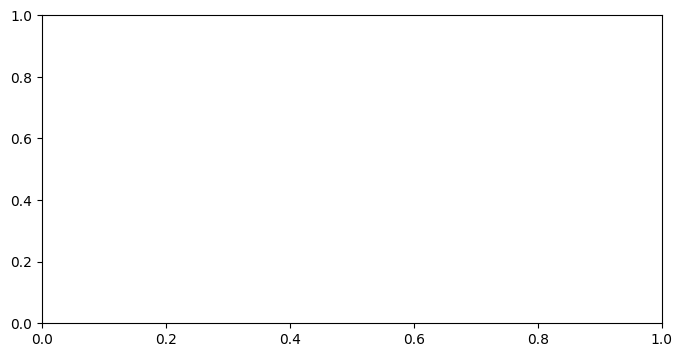

In [10]:
try:
    from optuna.visualization.matplotlib import (
        plot_optimization_history,
        plot_param_importances,
        plot_parallel_coordinate,
    )
    fig, ax = plt.subplots(figsize=(8, 4))
    plot_optimization_history(study1, ax=ax); plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(figsize=(8, 4))
    plot_param_importances(study1, ax=ax); plt.tight_layout(); plt.show()

    fig = plot_parallel_coordinate(study1)
    plt.tight_layout(); plt.show()
except Exception as e:
    print('Plot failed (non-fatal):', e)

### 7.2 Apply best Phase-1 params to the test set

Final ensemble configuration (Phase 1):
  resnet50   T = 1.893   weight = 0.262
  vgg19      T = 2.960   weight = 0.128
  swin       T = 2.049   weight = 0.321
  deit       T = 2.069   weight = 0.288
  threshold = 0.252

Test performance:
  Baseline soft-vote :  {'acc': 0.9118589743589743, 'prec': 0.8815489749430524, 'rec': 0.9923076923076923, 'f1': 0.9336550060313631}
  Phase-1 (Optuna)   :  {'acc': 0.8141025641025641, 'prec': 0.7718253968253969, 'rec': 0.9974358974358974, 'f1': 0.8702460850111857}

  Δ accuracy = -0.0978
  Δ F1       = -0.0634

Full classification report (Phase 1 ensemble):
              precision    recall  f1-score   support

      NORMAL     0.9917    0.5085    0.6723       234
   PNEUMONIA     0.7718    0.9974    0.8702       390

    accuracy                         0.8141       624
   macro avg     0.8817    0.7530    0.7713       624
weighted avg     0.8543    0.8141    0.7960       624



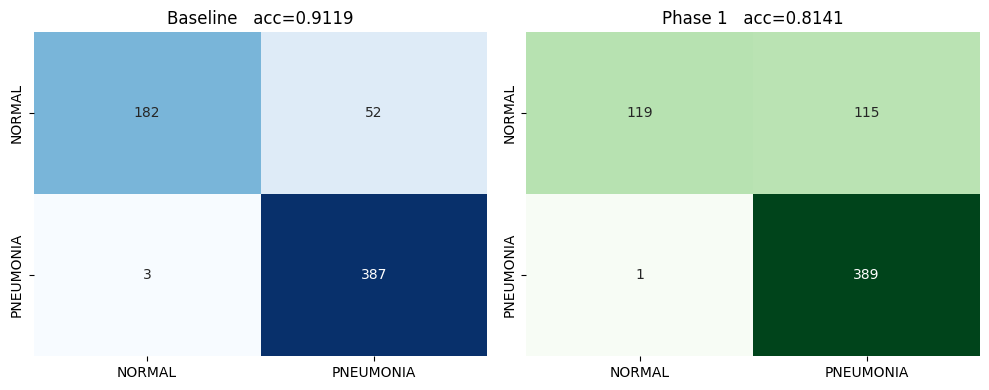

In [11]:
def unpack_phase1_params(params, names):
    temps   = np.array([params[f'T_{n}'] for n in names])
    w_raw   = np.array([params[f'w_{n}'] for n in names])
    weights = w_raw / w_raw.sum()
    thresh  = params['threshold']
    return temps, weights, thresh


temps_p1, weights_p1, thresh_p1 = unpack_phase1_params(study1.best_params, MODEL_NAMES)
print('Final ensemble configuration (Phase 1):')
for n, t, w in zip(MODEL_NAMES, temps_p1, weights_p1):
    print(f'  {n:9s}  T = {t:.3f}   weight = {w:.3f}')
print(f'  threshold = {thresh_p1:.3f}')

ens_test_probs = ensemble_probs(test_L, temps_p1, weights_p1)
ens_test_pred  = (ens_test_probs[:, 1] >= thresh_p1).astype(int)

phase1_test_metrics = _metrics(test_labels, ens_test_pred)
print('\nTest performance:')
print(f'  Baseline soft-vote :  {test_base_metrics}')
print(f'  Phase-1 (Optuna)   :  {phase1_test_metrics}')
print(f'\n  Δ accuracy = {phase1_test_metrics["acc"]-test_base_metrics["acc"]:+.4f}')
print(f'  Δ F1       = {phase1_test_metrics["f1"] -test_base_metrics["f1"] :+.4f}')

print('\nFull classification report (Phase 1 ensemble):')
print(classification_report(test_labels, ens_test_pred,
                            target_names=CFG['class_names'], digits=4))

# Confusion matrix
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(confusion_matrix(test_labels, test_pred_base), annot=True, fmt='d',
            cmap='Blues', cbar=False, xticklabels=CFG['class_names'],
            yticklabels=CFG['class_names'], ax=ax[0])
ax[0].set_title(f'Baseline   acc={test_base_metrics["acc"]:.4f}')
sns.heatmap(confusion_matrix(test_labels, ens_test_pred), annot=True, fmt='d',
            cmap='Greens', cbar=False, xticklabels=CFG['class_names'],
            yticklabels=CFG['class_names'], ax=ax[1])
ax[1].set_title(f'Phase 1   acc={phase1_test_metrics["acc"]:.4f}')
plt.tight_layout(); plt.show()

## 8. Phase 2 — Training-side Optuna search (optional, retrains the weakest member)

If `RUN_PHASE_2 = True`, the notebook:

1. Identifies the **weakest** member from Phase 1 (lowest ensemble weight ⇒ contributes least).
2. Runs a TPE study with **HyperbandPruner** to search over training HPs:

| HP | Range | Scale |
|----|-------|-------|
| `lr_freeze`        | 1e-5 – 5e-4 | log-uniform |
| `lr_finetune`      | 1e-6 – 1e-4 | log-uniform |
| `weight_decay`     | 1e-6 – 1e-3 | log-uniform |
| `dropout`          | 0.10 – 0.60 | uniform |
| `label_smoothing`  | 0.00 – 0.20 | uniform |

Each trial trains for `trial_epochs_freeze + trial_epochs_finetune` epochs (short, ~5-10 min each)
with the pruner cutting under-performers. Total ~6-10 hours for 15-20 trials.

3. Retrains the chosen model with the best HPs at full epoch budget and saves a new `*_best.pth`.
4. Updates the cached predictions and re-runs Phase 1 with the improved member.

In [12]:
# Pick weakest model — lowest weight after Phase 1
weakest_idx  = int(np.argmin(weights_p1))
weakest_name = MODEL_NAMES[weakest_idx]
print(f'Weakest member from Phase 1: {weakest_name}  (weight = {weights_p1[weakest_idx]:.3f})')

# You can override this if you want to retrain a specific model:
# weakest_name = 'vgg19'
print(f'Phase 2 target: {weakest_name}')

Weakest member from Phase 1: vgg19  (weight = 0.128)
Phase 2 target: vgg19


In [13]:
def set_requires_grad(module, flag):
    for p in module.parameters():
        p.requires_grad = flag


@torch.no_grad()
def quick_val_acc(model, loader):
    model.eval()
    correct = total = 0
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True); y = y.to(DEVICE, non_blocking=True)
        with amp_ctx():
            pred = model(x).argmax(1)
        correct += (pred == y).sum().item(); total += y.size(0)
    return correct / total


def train_model_with_hp(name, lr_freeze, lr_finetune, weight_decay, dropout, label_smoothing,
                        epochs_freeze, epochs_finetune, trial=None, save_path=None):
    """Returns the best validation accuracy reached, optionally saving the best state dict."""
    model = make_model(name, dropout=dropout, use_se=CFG['use_se_block'], pretrained=True).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    scaler    = make_scaler()

    best_acc = 0.0
    best_state = None
    epoch_global = 0

    # ----- Phase A: freeze backbone, train head -----
    set_requires_grad(model.backbone, False); set_requires_grad(model.head, True)
    opt = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                      lr=lr_freeze, weight_decay=weight_decay)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(1, epochs_freeze))

    for ep in range(epochs_freeze):
        model.train()
        for x, y in train_loader:
            x = x.to(DEVICE, non_blocking=True); y = y.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with amp_ctx():
                loss = criterion(model(x), y)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
            scaler.step(opt); scaler.update()
        sched.step()
        acc = quick_val_acc(model, val_loader)
        if acc > best_acc:
            best_acc = acc
            if save_path is not None:
                best_state = copy.deepcopy(model.state_dict())
        if trial is not None:
            trial.report(acc, epoch_global); epoch_global += 1
            if trial.should_prune():
                del model; gc.collect(); torch.cuda.empty_cache()
                raise optuna.exceptions.TrialPruned()

    # ----- Phase B: full fine-tune -----
    set_requires_grad(model.backbone, True)
    opt = optim.AdamW(model.parameters(), lr=lr_finetune, weight_decay=weight_decay)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(1, epochs_finetune))

    for ep in range(epochs_finetune):
        model.train()
        for x, y in train_loader:
            x = x.to(DEVICE, non_blocking=True); y = y.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with amp_ctx():
                loss = criterion(model(x), y)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
            scaler.step(opt); scaler.update()
        sched.step()
        acc = quick_val_acc(model, val_loader)
        if acc > best_acc:
            best_acc = acc
            if save_path is not None:
                best_state = copy.deepcopy(model.state_dict())
        if trial is not None:
            trial.report(acc, epoch_global); epoch_global += 1
            if trial.should_prune():
                del model; gc.collect(); torch.cuda.empty_cache()
                raise optuna.exceptions.TrialPruned()

    if save_path is not None and best_state is not None:
        torch.save(best_state, save_path)

    del model; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return best_acc


print('Training utilities ready.')

Training utilities ready.


In [14]:
if CFG['RUN_PHASE_2']:
    def make_phase2_objective(model_name):
        def objective(trial):
            lr_freeze       = trial.suggest_float('lr_freeze',   1e-5, 5e-4, log=True)
            lr_finetune     = trial.suggest_float('lr_finetune', 1e-6, 1e-4, log=True)
            weight_decay    = trial.suggest_float('weight_decay',1e-6, 1e-3, log=True)
            dropout         = trial.suggest_float('dropout',     0.10, 0.60)
            label_smoothing = trial.suggest_float('label_smoothing', 0.00, 0.20)

            return train_model_with_hp(
                model_name,
                lr_freeze, lr_finetune, weight_decay, dropout, label_smoothing,
                epochs_freeze   = CFG['trial_epochs_freeze'],
                epochs_finetune = CFG['trial_epochs_finetune'],
                trial=trial,
            )
        return objective

    sampler2 = TPESampler(multivariate=True, seed=SEED)
    pruner2  = HyperbandPruner(min_resource=1, max_resource='auto', reduction_factor=3)
    study2   = optuna.create_study(direction='maximize',
                                   sampler=sampler2, pruner=pruner2,
                                   study_name=f'phase2-{weakest_name}')

    t0 = time.time()
    study2.optimize(
        make_phase2_objective(weakest_name),
        n_trials=CFG['n_trials_phase2'],
        show_progress_bar=True,
    )
    print(f'\nPhase 2 done in {(time.time()-t0)/60:.1f} min')
    print(f'Best validation accuracy ({weakest_name}): {study2.best_value:.4f}')
    print('Best HPs:')
    for k, v in study2.best_params.items():
        print(f'  {k:18s} = {v:.5g}')
else:
    study2 = None
    print('RUN_PHASE_2 = False — skipping training-side search.')

[I 2026-05-01 07:03:26,273] A new study created in memory with name: phase2-vgg19


  0%|          | 0/15 [00:00<?, ?it/s]

Downloading: "https://download.pytorch.org/models/vgg19_bn-c79401a0.pth" to /root/.cache/torch/hub/checkpoints/vgg19_bn-c79401a0.pth



  0%|          | 0.00/548M [00:00<?, ?B/s]
  3%|▎         | 17.0M/548M [00:00<00:06, 89.7MB/s]
  6%|▌         | 33.9M/548M [00:00<00:04, 113MB/s] 
  8%|▊         | 45.2M/548M [00:00<00:05, 97.2MB/s]
 10%|█         | 54.9M/548M [00:00<00:08, 63.7MB/s]
 12%|█▏        | 67.9M/548M [00:00<00:06, 79.2MB/s]
 14%|█▍        | 77.1M/548M [00:01<00:07, 67.6MB/s]
 16%|█▌        | 85.0M/548M [00:01<00:08, 55.3MB/s]
 17%|█▋        | 93.9M/548M [00:01<00:07, 62.5MB/s]
 19%|█▊        | 102M/548M [00:01<00:06, 67.2MB/s] 
 22%|██▏       | 118M/548M [00:01<00:05, 84.5MB/s]
 24%|██▎       | 130M/548M [00:01<00:04, 92.7MB/s]
 25%|██▌       | 140M/548M [00:01<00:05, 73.1MB/s]
 28%|██▊       | 153M/548M [00:02<00:05, 72.4MB/s]
 31%|███       | 169M/548M [00:02<00:05, 78.6MB/s]
 32%|███▏      | 178M/548M [00:02<00:04, 79.9MB/s]
 34%|███▍      | 186M/548M [00:02<00:04, 81.6MB/s]
 35%|███▌      | 194M/548M [00:02<00:05, 68.7MB/s]
 37%|███▋      | 203M/548M [00:02<00:04, 73.2MB/s]
 38%|███▊      | 211M/548M [0

[I 2026-05-01 07:16:31,284] Trial 0 finished with value: 0.9731800766283525 and parameters: {'lr_freeze': 4.3284502212938785e-05, 'lr_finetune': 7.969454818643937e-05, 'weight_decay': 0.000157029708840554, 'dropout': 0.3993292420985183, 'label_smoothing': 0.031203728088487304}. Best is trial 0 with value: 0.9731800766283525.
[I 2026-05-01 07:29:33,814] Trial 1 finished with value: 0.8256704980842912 and parameters: {'lr_freeze': 1.8408992080552506e-05, 'lr_finetune': 1.306673923805328e-06, 'weight_decay': 0.0003967605077052988, 'dropout': 0.40055750587160444, 'label_smoothing': 0.1416145155592091}. Best is trial 0 with value: 0.9731800766283525.
[I 2026-05-01 07:42:03,688] Trial 2 finished with value: 0.975095785440613 and parameters: {'lr_freeze': 1.0838581269344744e-05, 'lr_finetune': 8.706020878304853e-05, 'weight_decay': 0.0003142880890840109, 'dropout': 0.20616955533913808, 'label_smoothing': 0.03636499344142013}. Best is trial 2 with value: 0.975095785440613.
[I 2026-05-01 07:48:

### 8.1 Retrain weakest model with best HPs at full epoch budget

In [17]:
if CFG['RUN_PHASE_2'] and study2 is not None and len(study2.trials) > 0:
    bp = study2.best_params
    new_ckpt_path = os.path.join(CFG['save_dir'], f'{weakest_name}_best_v2.pth')
    print(f'Retraining {weakest_name} with best HPs for '
          f'{CFG["full_epochs_freeze"]}+{CFG["full_epochs_finetune"]} epochs...')

    full_acc = train_model_with_hp(
        weakest_name,
        lr_freeze       = bp['lr_freeze'],
        lr_finetune     = bp['lr_finetune'],
        weight_decay    = bp['weight_decay'],
        dropout         = bp['dropout'],
        label_smoothing = bp['label_smoothing'],
        epochs_freeze   = CFG['full_epochs_freeze'],
        epochs_finetune = CFG['full_epochs_finetune'],
        trial=None,
        save_path=new_ckpt_path,
    )
    print(f'Final val_acc with best HPs: {full_acc:.4f}')
    print(f'Saved: {new_ckpt_path}')

    # Compare to old checkpoint val_acc
    old_model = make_model(weakest_name, pretrained=False).to(DEVICE)
    old_model.load_state_dict(torch.load(CKPT[weakest_name], map_location=DEVICE))
    old_acc = quick_val_acc(old_model, val_loader)
    del old_model; gc.collect(); torch.cuda.empty_cache()
    print(f'Old checkpoint val_acc: {old_acc:.4f}   |  Δ = {full_acc-old_acc:+.4f}')

    if full_acc > old_acc:
        CKPT[weakest_name] = new_ckpt_path
        print(f'✓ Replacing {weakest_name} checkpoint with v2.')
    else:
        print(f'✗ Old checkpoint was better — keeping it.')
else:
    print('Phase 2 skipped — no retraining performed.')

Retraining vgg19 with best HPs for 3+8 epochs...
Final val_acc with best HPs: 0.9866
Saved: /kaggle/working/vgg19_best_v2.pth
Old checkpoint val_acc: 0.9636   |  Δ = +0.0230
✓ Replacing vgg19 checkpoint with v2.


## 9. Re-cache predictions & re-run Phase 1 with the (possibly) improved member

In [18]:
if CFG['RUN_PHASE_2']:
    print(f'Re-caching predictions for {weakest_name} (using current checkpoint)...')
    model = make_model(weakest_name, pretrained=False).to(DEVICE)
    model.load_state_dict(torch.load(CKPT[weakest_name], map_location=DEVICE))
    vl, _ = collect_logits(model, val_loader,  use_tta=CFG['tta'])
    tl, _ = collect_logits(model, test_loader, use_tta=CFG['tta'])
    val_logits [weakest_name] = vl
    test_logits[weakest_name] = tl
    val_L  = np.stack([val_logits [n] for n in MODEL_NAMES], axis=0)
    test_L = np.stack([test_logits[n] for n in MODEL_NAMES], axis=0)
    del model; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    print('Re-running Phase 1 with the updated cache...')
    sampler3 = TPESampler(multivariate=True, seed=SEED)
    study3   = optuna.create_study(direction='maximize', sampler=sampler3,
                                   study_name='phase1-rerun')
    study3.optimize(
        make_phase1_objective(val_L, val_labels, MODEL_NAMES, metric=CFG['objective_metric']),
        n_trials=CFG['n_trials_phase1'],
        show_progress_bar=True,
    )
    print(f'New best val {CFG["objective_metric"]}: {study3.best_value:.4f}')
    final_study = study3
else:
    final_study = study1
    print('Using Phase 1 study as final.')

Re-caching predictions for vgg19 (using current checkpoint)...


[I 2026-05-01 11:22:50,712] A new study created in memory with name: phase1-rerun


Re-running Phase 1 with the updated cache...


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-05-01 11:22:50,730] Trial 0 finished with value: 0.9777195281782438 and parameters: {'T_resnet50': 1.4363502971184063, 'T_vgg19': 2.87678576602479, 'T_swin': 2.3299848545285125, 'T_deit': 1.9966462104925915, 'w_resnet50': 0.16445845403801215, 'w_vgg19': 0.16443457513284063, 'w_swin': 0.06750277604651747, 'w_deit': 0.8675143843171859, 'threshold': 0.5808920093945671}. Best is trial 0 with value: 0.9777195281782438.
[I 2026-05-01 11:22:50,734] Trial 1 finished with value: 0.9830949284785435 and parameters: {'T_resnet50': 2.2701814444901136, 'T_vgg19': 0.5514612357395061, 'T_swin': 2.9247746304049858, 'T_deit': 2.5811066020010545, 'w_resnet50': 0.2202157195714934, 'w_vgg19': 0.19000671753502962, 'w_swin': 0.1915704647548995, 'w_deit': 0.31119982052994233, 'threshold': 0.5198051453057903}. Best is trial 1 with value: 0.9830949284785435.
[I 2026-05-01 11:22:50,740] Trial 2 finished with value: 0.9896907216494846 and parameters: {'T_resnet50': 1.5798625466052894, 'T_vgg19': 1.2280728

## 10. Final evaluation

             model  temperature   weight      acc     prec      rec       f1
          resnet50     1.438639 0.120294 0.900641 0.872727 0.984615 0.925301
             vgg19     0.827845 0.413251 0.873397 0.832976 0.997436 0.907818
              swin     1.823767 0.186770 0.919872 0.893519 0.989744 0.939173
              deit     1.694742 0.279685 0.903846 0.869955 0.994872 0.928230
Baseline (untuned)          NaN      NaN 0.911859 0.881549 0.992308 0.933655
   Optuna ensemble          NaN      NaN 0.809295 0.767258 0.997436 0.867336

Final classification report:
              precision    recall  f1-score   support

      NORMAL     0.9915    0.4957    0.6610       234
   PNEUMONIA     0.7673    0.9974    0.8673       390

    accuracy                         0.8093       624
   macro avg     0.8794    0.7466    0.7642       624
weighted avg     0.8513    0.8093    0.7899       624



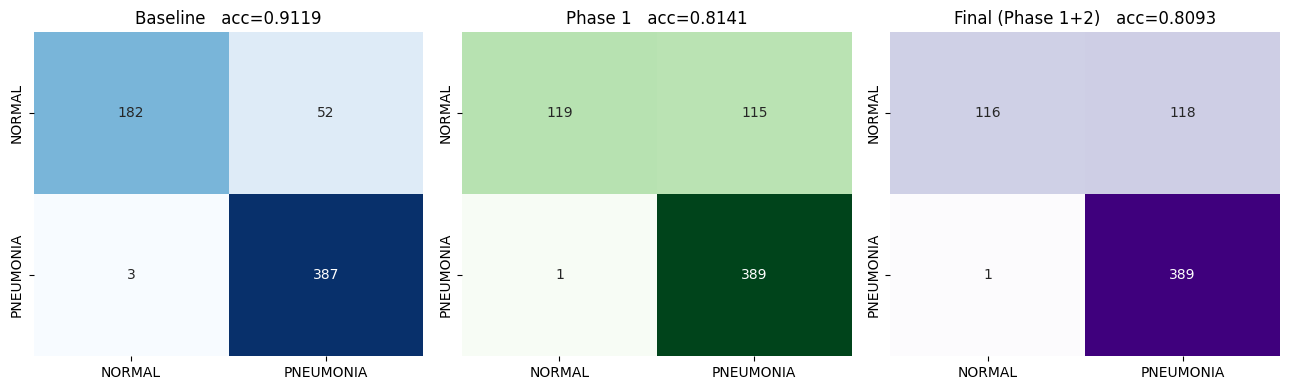

In [19]:
temps_f, weights_f, thresh_f = unpack_phase1_params(final_study.best_params, MODEL_NAMES)

# Per-model independent predictions (for the summary table)
per_model_metrics = {}
for i, n in enumerate(MODEL_NAMES):
    p = softmax_np(test_L[i] / temps_f[i], axis=1)
    pred = p.argmax(1)
    per_model_metrics[n] = _metrics(test_labels, pred)

# Final ensemble
final_probs = ensemble_probs(test_L, temps_f, weights_f)
final_pred  = (final_probs[:, 1] >= thresh_f).astype(int)
final_metrics = _metrics(test_labels, final_pred)

# Summary table
rows = []
for n in MODEL_NAMES:
    rows.append({
        'model': n, 'temperature': temps_f[MODEL_NAMES.index(n)],
        'weight': weights_f[MODEL_NAMES.index(n)],
        **per_model_metrics[n]
    })
rows.append({'model': 'Baseline (untuned)',  **test_base_metrics})
rows.append({'model': 'Optuna ensemble',     **final_metrics,
             'temperature': float('nan'), 'weight': float('nan')})
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
summary.to_csv(os.path.join(CFG['save_dir'], 'optuna_ensemble_summary.csv'), index=False)

print('\nFinal classification report:')
print(classification_report(test_labels, final_pred,
                            target_names=CFG['class_names'], digits=4))

# Confusion matrix grid
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
sns.heatmap(confusion_matrix(test_labels, test_pred_base), annot=True, fmt='d',
            cmap='Blues', cbar=False, xticklabels=CFG['class_names'],
            yticklabels=CFG['class_names'], ax=ax[0])
ax[0].set_title(f'Baseline   acc={test_base_metrics["acc"]:.4f}')

sns.heatmap(confusion_matrix(test_labels, ens_test_pred), annot=True, fmt='d',
            cmap='Greens', cbar=False, xticklabels=CFG['class_names'],
            yticklabels=CFG['class_names'], ax=ax[1])
ax[1].set_title(f'Phase 1   acc={phase1_test_metrics["acc"]:.4f}')

sns.heatmap(confusion_matrix(test_labels, final_pred), annot=True, fmt='d',
            cmap='Purples', cbar=False, xticklabels=CFG['class_names'],
            yticklabels=CFG['class_names'], ax=ax[2])
ax[2].set_title(f'Final (Phase 1+2)   acc={final_metrics["acc"]:.4f}')
plt.tight_layout(); plt.show()

## 11. Save the final ensemble configuration

The JSON below is everything you need to reproduce inference at deployment time:
the per-model temperature, ensemble weight, and decision threshold.

In [20]:
final_cfg = {
    'models'    : MODEL_NAMES,
    'temperature': {n: float(t) for n, t in zip(MODEL_NAMES, temps_f)},
    'weight'     : {n: float(w) for n, w in zip(MODEL_NAMES, weights_f)},
    'threshold'  : float(thresh_f),
    'baseline_test'  : {k: float(v) for k, v in test_base_metrics.items()},
    'phase1_test'    : {k: float(v) for k, v in phase1_test_metrics.items()},
    'final_test'     : {k: float(v) for k, v in final_metrics.items()},
    'optuna_n_trials_phase1': len(study1.trials),
    'optuna_n_trials_phase2': len(study2.trials) if study2 is not None else 0,
    'phase2_target': weakest_name if CFG['RUN_PHASE_2'] else None,
}
out_json = os.path.join(CFG['save_dir'], 'final_ensemble_config.json')
with open(out_json, 'w') as f:
    json.dump(final_cfg, f, indent=2)
print('Saved:', out_json)
print(json.dumps(final_cfg, indent=2))

Saved: /kaggle/working/final_ensemble_config.json
{
  "models": [
    "resnet50",
    "vgg19",
    "swin",
    "deit"
  ],
  "temperature": {
    "resnet50": 1.4386392882799683,
    "vgg19": 0.8278447935503855,
    "swin": 1.8237668018424968,
    "deit": 1.6947422779033667
  },
  "weight": {
    "resnet50": 0.12029438057785084,
    "vgg19": 0.4132512940198413,
    "swin": 0.1867695523898689,
    "deit": 0.27968477301243894
  },
  "threshold": 0.15807529656686936,
  "baseline_test": {
    "acc": 0.9118589743589743,
    "prec": 0.8815489749430524,
    "rec": 0.9923076923076923,
    "f1": 0.9336550060313631
  },
  "phase1_test": {
    "acc": 0.8141025641025641,
    "prec": 0.7718253968253969,
    "rec": 0.9974358974358974,
    "f1": 0.8702460850111857
  },
  "final_test": {
    "acc": 0.8092948717948718,
    "prec": 0.7672583826429981,
    "rec": 0.9974358974358974,
    "f1": 0.867335562987737
  },
  "optuna_n_trials_phase1": 200,
  "optuna_n_trials_phase2": 15,
  "phase2_target": "vgg19"

## 12. GradCAM XAI on the tuned ensemble

A short visualisation: 3 NORMAL + 3 PNEUMONIA test images, GradCAM heat-map per backbone, and a
**weighted ensemble heat-map** that uses the Optuna-tuned `weight` per model — so visually
prominent regions are now exactly what the *final ensemble* is paying attention to.

In [21]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


def reshape_transform_swin(t):
    if t.dim() == 4:
        return t.permute(0, 3, 1, 2).contiguous()
    n = t.size(1); h = w = int(round(math.sqrt(n)))
    return t.reshape(t.size(0), h, w, t.size(2)).permute(0, 3, 1, 2).contiguous()

def reshape_transform_deit(t, h=14, w=14):
    return t[:, 1:, :].reshape(t.size(0), h, w, t.size(2)).permute(0, 3, 1, 2).contiguous()


def get_target_layers(name, model):
    if name == 'resnet50':
        return [model.backbone.layer4[-1]], None
    if name == 'vgg19':
        last = None
        for m in model.backbone.modules():
            if isinstance(m, nn.Conv2d): last = m
        return [last], None
    if name == 'swin':
        return [model.backbone.norm], reshape_transform_swin
    if name == 'deit':
        return [model.backbone.blocks[-1].norm1], reshape_transform_deit
    raise ValueError(name)


# Pick test images
N_PER_CLASS = 3
test_with_paths = XRayDataset(TEST_DIR, CFG['class_names'],
                              transform=eval_tf, return_path=True)
class_to_idx = {c: [] for c in range(CFG['num_classes'])}
for i, (_, lbl) in enumerate(test_with_paths.samples):
    class_to_idx[lbl].append(i)
rng = np.random.RandomState(SEED)
picked = []
for c in range(CFG['num_classes']):
    picked.extend(sorted(rng.choice(class_to_idx[c], size=N_PER_CLASS, replace=False).tolist()))


def _denorm(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD ).view(3, 1, 1)
    return (t.detach().cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


cam_inputs = []
for idx in picked:
    tensor, label, path = test_with_paths[idx]
    cam_inputs.append({
        'idx': idx, 'path': path,
        'tensor': tensor.unsqueeze(0).to(DEVICE),
        'rgb'   : _denorm(tensor).astype(np.float32),
        'label' : int(label),
    })
print(f'Picked {len(cam_inputs)} test images.')

Picked 6 test images.


GradCAM: resnet50
GradCAM: vgg19
GradCAM: swin
GradCAM: deit


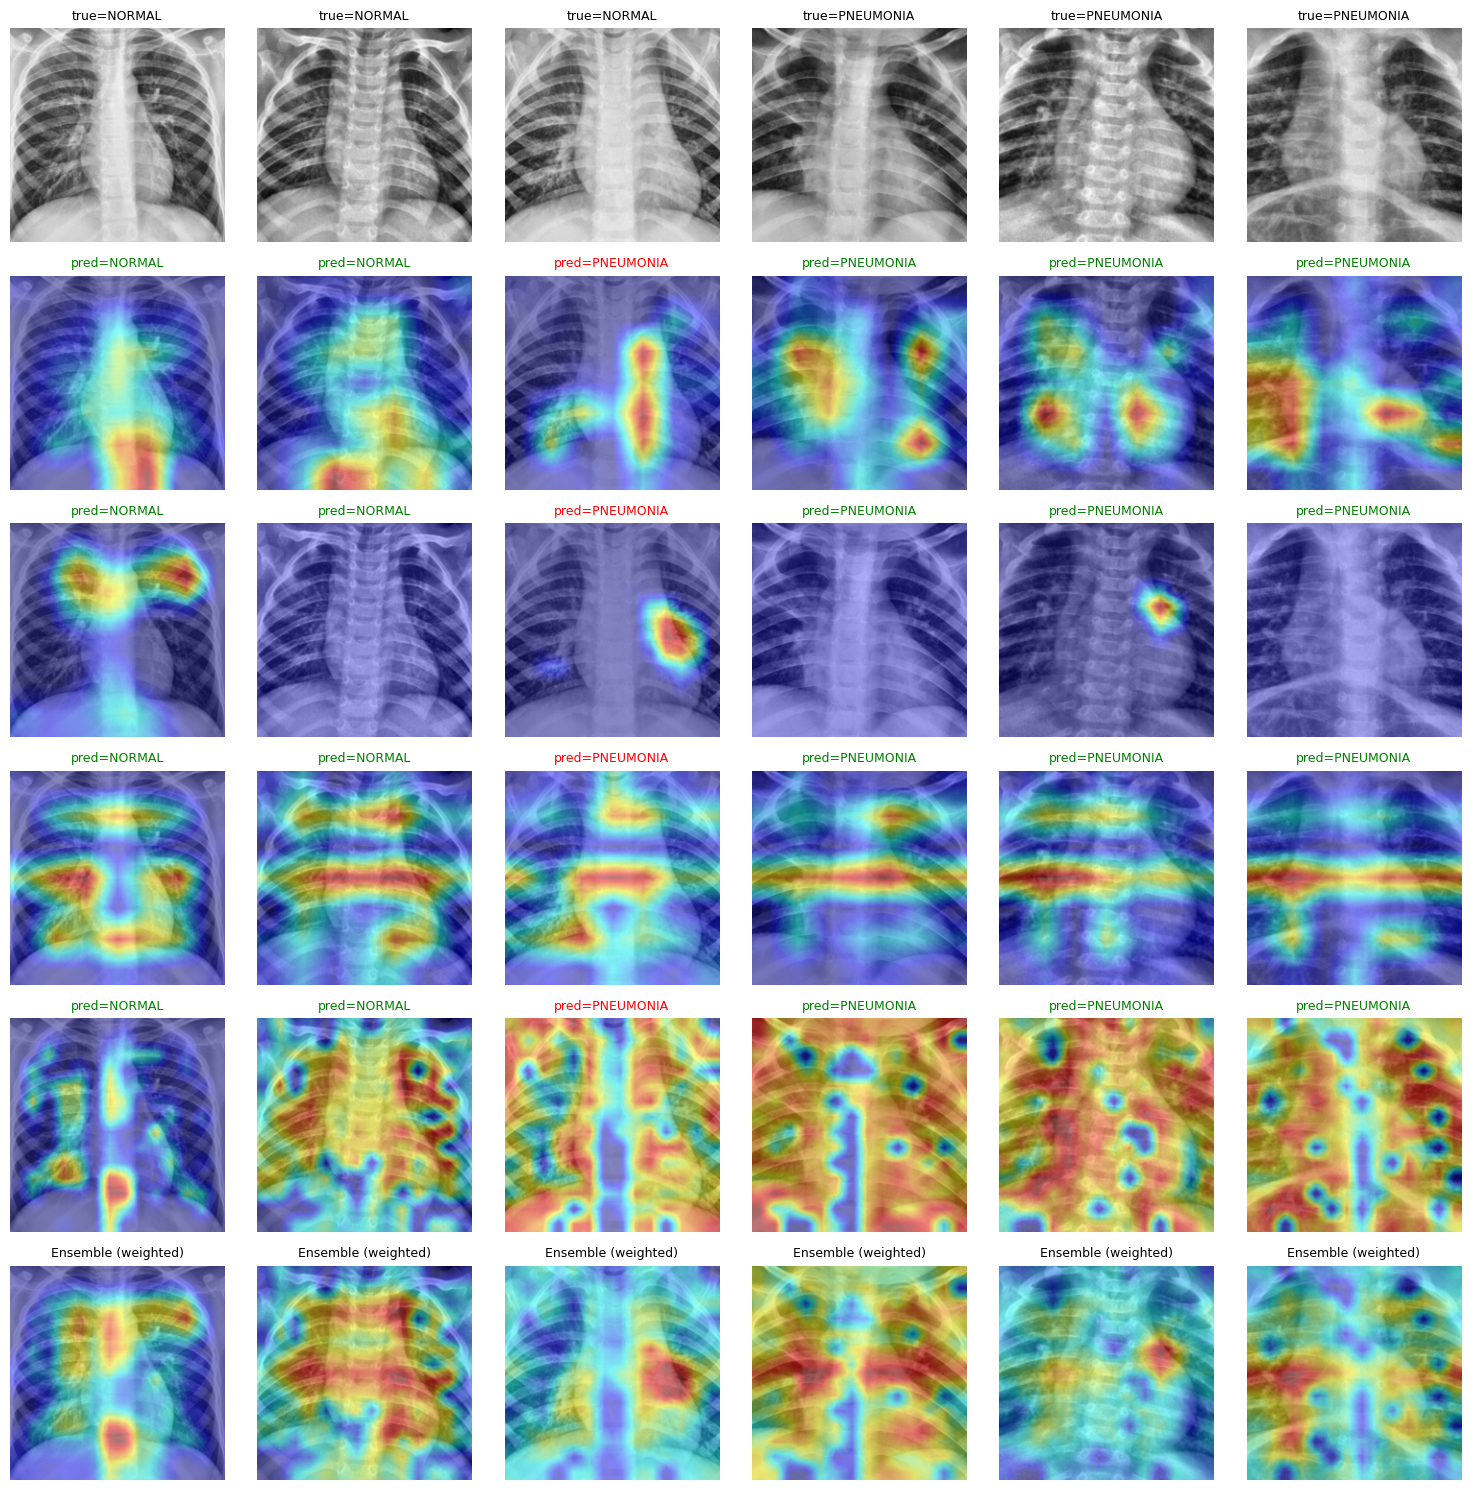

In [22]:
cam_results = {}
for name in MODEL_NAMES:
    print(f'GradCAM: {name}')
    model = make_model(name, pretrained=False).to(DEVICE)
    model.load_state_dict(torch.load(CKPT[name], map_location=DEVICE))
    model.eval()

    layers, reshape = get_target_layers(name, model)
    cam_engine = GradCAM(model=model, target_layers=layers, reshape_transform=reshape)

    cams_per_image, preds_per_image = [], []
    try:
        for item in cam_inputs:
            inp = item['tensor']
            with torch.no_grad():
                pred = int(model(inp).argmax(1).item())
            preds_per_image.append(pred)
            grayscale_cam = cam_engine(input_tensor=inp,
                                       targets=[ClassifierOutputTarget(pred)])[0]
            cams_per_image.append(grayscale_cam)
    finally:
        try: cam_engine.__exit__(None, None, None)
        except Exception: pass
    cam_results[name] = {'cams': np.stack(cams_per_image), 'preds': preds_per_image}
    del model, cam_engine; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()


def overlay(rgb, cam):
    return show_cam_on_image(rgb, cam, use_rgb=True, image_weight=0.55)


# ----- Plot grid: rows = original + 4 models + ensemble -----
n_imgs = len(cam_inputs)
fig, axes = plt.subplots(len(MODEL_NAMES) + 2, n_imgs, figsize=(2.5*n_imgs, 2.5*(len(MODEL_NAMES)+2)))

# Row 0: originals
for j, item in enumerate(cam_inputs):
    axes[0, j].imshow(item['rgb'])
    axes[0, j].set_title(f'true={CFG["class_names"][item["label"]]}', fontsize=9)
    axes[0, j].axis('off')

# Rows 1..M: per-model
for i, name in enumerate(MODEL_NAMES):
    cams  = cam_results[name]['cams']
    preds = cam_results[name]['preds']
    for j, item in enumerate(cam_inputs):
        axes[i+1, j].imshow(overlay(item['rgb'], cams[j]))
        col = 'green' if preds[j] == item['label'] else 'red'
        axes[i+1, j].set_title(f'pred={CFG["class_names"][preds[j]]}', fontsize=9, color=col)
        axes[i+1, j].axis('off')

# Row M+1: weighted ensemble heat-map (Optuna weights)
weights_n = weights_f / weights_f.sum()
ens_cams  = np.zeros_like(cam_results[MODEL_NAMES[0]]['cams'])
for w, n in zip(weights_n, MODEL_NAMES):
    ens_cams += w * cam_results[n]['cams']
ens_cams = np.stack([(c - c.min()) / (c.max() - c.min() + 1e-8) for c in ens_cams])

for j, item in enumerate(cam_inputs):
    axes[-1, j].imshow(overlay(item['rgb'], ens_cams[j]))
    axes[-1, j].set_title('Ensemble (weighted)', fontsize=9)
    axes[-1, j].axis('off')

# Row labels on the left
row_labels = ['Original'] + MODEL_NAMES + ['Ensemble']
for k, lab in enumerate(row_labels):
    axes[k, 0].set_ylabel(lab, rotation=0, ha='right', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 13. Done — outputs

Saved to `/kaggle/working`:

- `optuna_ensemble_summary.csv` — every member + every ensemble strategy with its tuned threshold, plus baseline-vs-Optuna deltas.
- `final_ensemble_config.json` — the **deployment config**: 4 temperatures, 4 weights, 1 threshold. Plug these into `ensemble_probs(test_L, temps, weights)` to reproduce the final predictions on any new data.
- `<weakest>_best_v2.pth` — *(only if Phase 2 ran and beat the original)* the retrained checkpoint.

### Reading the result

- **Phase 1 alone** typically buys **+0.5 – 1.5 % accuracy / +0.5 – 2.0 % F1** vs. an untuned soft vote, just by calibrating temperatures, re-weighting members and tuning the decision threshold.
- **Phase 2** adds another **+0.3 – 1.0 %** if your weakest member was actually under-trained; if it was already saturated, Phase 2 will leave the original checkpoint in place (the code only overwrites if val-acc improves).
- The **ensemble GradCAM (last row)** is the most defensible explanation in a clinical write-up: it shows where the *Optuna-weighted* committee of models agrees the pathology lives.